# CDD-SVA example: OMC-1

This notebook compares two **beam-, grid-, and WCS-matched** OMC-1 intensity maps using CDD Scale-Vector Alignment (SVA).

The repository includes two small processed cutouts:

- `omc1_image1.fits`: H$_2$ column density
- `omc1_image2.fits`: C$^{18}$O(1--0) integrated intensity

Both are sampled on a 5 arcsec grid and matched to a 36 arcsec effective resolution.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from cdd_sva import scale_similarity

In [2]:
cwd = Path.cwd()

if (cwd / 'data').is_dir():
    # Notebook launched from examples/
    data_dir = cwd / 'data'
elif (cwd / 'examples' / 'data').is_dir():
    # Notebook launched from the repository root
    data_dir = cwd / 'examples' / 'data'
else:
    raise FileNotFoundError('Cannot find the examples/data directory.')

file1 = data_dir / 'omc1_image1.fits'
file2 = data_dir / 'omc1_image2.fits'

if not file1.exists() or not file2.exists():
    raise FileNotFoundError(
        f'Expected example files:\n  {file1}\n  {file2}'
    )

print('Image 1:', file1.resolve())
print('Image 2:', file2.resolve())

Image 1: /home/mengke/Disk1/k/complexity/code/CDD-SVA/examples/data/omc1_image1.fits
Image 2: /home/mengke/Disk1/k/complexity/code/CDD-SVA/examples/data/omc1_image2.fits


In [3]:
I1 = np.squeeze(fits.getdata(file1)).astype(float)
I2 = np.squeeze(fits.getdata(file2)).astype(float)

if I1.ndim != 2 or I2.ndim != 2:
    raise ValueError('The example expects two 2-D FITS images.')

print('I1 shape:', I1.shape)
print('I2 shape:', I2.shape)

I1 shape: (144, 144)
I2 shape: (144, 144)


## Run SVA

The defaults reproduce the paper settings. Set `use_gpu=True` after installing a compatible PyTorch build if GPU acceleration is desired.

In [4]:
result = scale_similarity(
    I1,
    I2,
    use_gpu=False,
    mode='log',
)

print(f'S_crit = {result.S_crit:.3f}')
print('CDD scales [pix] =', result.scales)


--- STAGE 1: High-res decomposition (scales <= 5.0) ---
Running Engine in CONSTRAINED (standard) mode on CPU.
Channel 0: Scale < 4.00 pixels, Iterations: 33
Channel 1: Scale < 8.00 pixels, Iterations: 100
Channel 2: Scale < 16.00 pixels, Iterations: 100

--- STAGE 2: Fixed-grid decomposition (scales > 5.0) ---
Running Engine in CONSTRAINED (standard) mode on CPU.
Channel 0: Scale < 8.00 pixels, Iterations: 33
Channel 1: Scale < 16.00 pixels, Iterations: 100
Channel 2: Scale < 32.00 pixels, Iterations: 100
Channel 3: Scale < 64.00 pixels, Iterations: 100

--- STAGE 1: High-res decomposition (scales <= 5.0) ---
Running Engine in CONSTRAINED (standard) mode on CPU.
Channel 0: Scale < 4.00 pixels, Iterations: 33
Channel 1: Scale < 8.00 pixels, Iterations: 100
Channel 2: Scale < 16.00 pixels, Iterations: 100

--- STAGE 2: Fixed-grid decomposition (scales > 5.0) ---
Running Engine in CONSTRAINED (standard) mode on CPU.
Channel 0: Scale < 8.00 pixels, Iterations: 33
Channel 1: Scale < 16.00 

## Pixel-wise similarity

`S_pix` locates where the two images share the same local distribution of intensity across spatial scale.

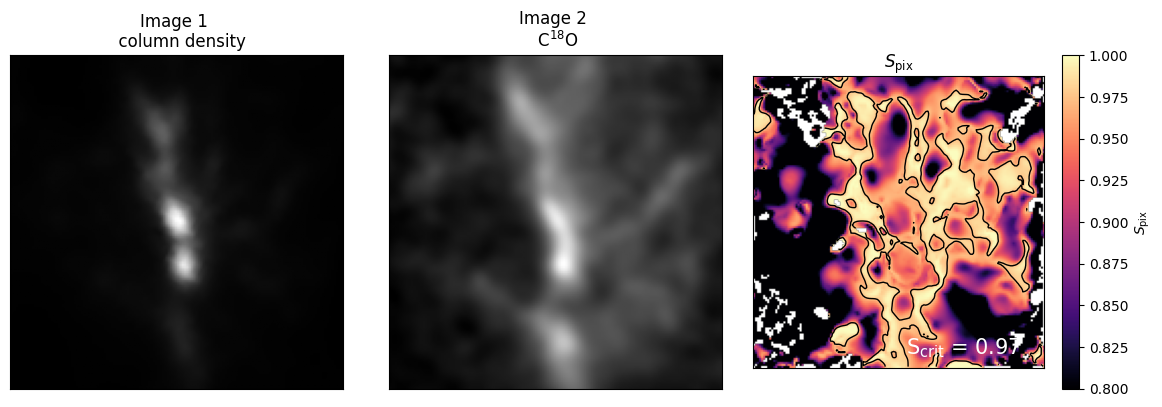

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].imshow(I1, origin='lower', cmap='gray')
ax[0].set_title('Image 1 \n  column density')

ax[1].imshow(I2, origin='lower', cmap='gray')
ax[1].set_title('Image 2 \n '+r'C$^{18}$O')

im = ax[2].imshow(result.S_pix, origin='lower', cmap='magma', vmin=0.8, vmax=1)
ax[2].contour(result.S_pix, levels=[result.S_crit], colors='k', linewidths=1)
ax[2].set_title(r'$S_{\rm pix}$')
fig.colorbar(im, ax=ax[2], label=r'$S_{\rm pix}$')
plt.text(75,6,f'S$_{{\\rm crit}}$ = {result.S_crit:.2f}', color='w', fontsize=15)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()

## Scale-wise similarity

`S_scale(l)` compares the two CDD component maps at each spatial scale.

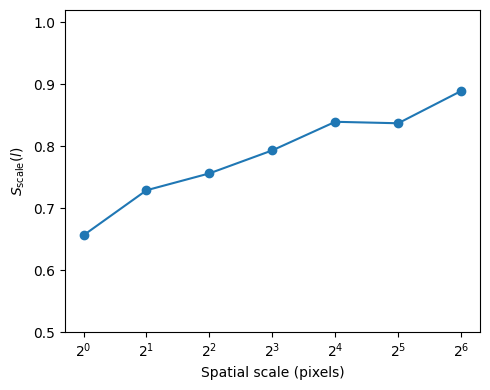

In [7]:
good = np.isfinite(result.S_scale)

plt.figure(figsize=(5, 4))
plt.plot(result.scales[good], result.S_scale[good], '-o')
plt.xscale('log', base=2)
plt.ylim(0.5, 1.02)
plt.xlabel('Spatial scale (pixels)')
plt.ylabel(r'$S_{\rm scale}(l)$')
plt.tight_layout()
plt.show()